# W/M Information Test Notebook

This notebook tests the `W_M_calculator` for two discrete processes.

In [1]:
import numpy as np
import sys
import os

# Add wimfo to path if not installed globally
sys.path.append('/Users/hr1015/Projects/DelaySynergy/Z - scoring issue/wimfo')

from wimfo.W_M_Info import W_M_calculator

### Process 1: $X_{t+1} = \text{XOR}(X_t, Y_t)$ and $Y_t$ is i.i.d. binary

In this process, $X$ integrates information synergistically from both its own past and the past of $Y$. Because the dependency is strictly higher-order, we expect M-information to be high and W-information to be low.

In [2]:
np.random.seed(42)
N = 10000

Y1 = np.random.randint(0, 2, N)
X1 = np.zeros(N, dtype=int)
X1[0] = np.random.randint(0, 2)

for t in range(N - 1):
    X1[t+1] = X1[t] ^ Y1[t]

# Create the input array of shape (4, N-1)
# Row 0: Source 1 (X at t)
# Row 1: Source 2 (Y at t)
# Row 2: Target 1 (X at t+1)
# Row 3: Target 2 (Y at t+1)
data1 = np.array([X1[:-1], Y1[:-1], X1[1:], Y1[1:]])

W1, M1 = W_M_calculator(data1, type="discrete", option="data", alphabet_size=2)
print(f"Process 1 (XOR) -> W-info: {W1:.4f} bits, M-info: {M1:.4f} bits")

Process 1 (XOR) -> W-info: 0.0000 bits, M-info: 1.0000 bits


### Process 2: $X_{t+1} = Y_t$ and $Y_t$ is i.i.d. binary

In this process, $X$ copies the past of $Y$ directly, effectively moving information from $Y$ to $X$ via a lower-order pairwise dependency. Thus, we expect W-information to be high and M-information to be zero.

In [3]:
Y2 = np.random.randint(0, 2, N)
X2 = np.zeros(N, dtype=int)
X2[0] = np.random.randint(0, 2)

for t in range(N - 1):
    X2[t+1] = Y2[t]

data2 = np.array([X2[:-1], Y2[:-1], X2[1:], Y2[1:]])

W2, M2 = W_M_calculator(data2, type="discrete", option="data", alphabet_size=2)
print(f"Process 2 (COPY) -> W-info: {W2:.4f} bits, M-info: {M2:.4f} bits")

Process 2 (COPY) -> W-info: 1.0000 bits, M-info: 0.0000 bits


In [4]:
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm
except ImportError:
    def tqdm(iterable, *args, **kwargs):
        return iterable
from numit_discrete_optimized import find_transition_for_target, mutual_info_numba

def estimate_joint_pmf(X, Y, tau):
    X = np.asarray(X)
    Y = np.asarray(Y)
    X_t = X[:-tau]
    Y_t = Y[:-tau]
    X_f = X[tau:]
    Y_f = Y[tau:]
    data = np.stack([X_t, Y_t, X_f, Y_f])
    bins = [np.array([0, 1, 2])] * 4
    pmf, _ = np.histogramdd(data.T, bins=bins)
    return pmf / np.sum(pmf)

def calculate_tdmi(pmf):
    P_4x4 = pmf.reshape((4, 4))
    return mutual_info_numba(P_4x4)

def generate_single_null_wm(target_tdmi, max_tries=500, max_retries=100):
    for _ in range(max_retries):
        f1, f2, eta, P_4x4 = find_transition_for_target(target_tdmi, max_tries=max_tries)
        pmf_4d = P_4x4.reshape((2, 2, 2, 2))
        pmf_4d = pmf_4d + 1e-4
        pmf_4d = pmf_4d / np.sum(pmf_4d)
        try:
            W, M = W_M_calculator(
                input=pmf_4d,
                type="discrete",
                option="distr",
                alphabet_size=2
            )
            return W, M, f1, f2, eta
        except AssertionError:
            continue
    raise RuntimeError(f"Failed to generate a valid null after {max_retries} retries.")


### Null Distribution for Process 1 (XOR)

Calculating Nulls for Process 1 (XOR)...
Target TDMI 1: 1.0000 bits


  0%|          | 0/100 [00:00<?, ?it/s]

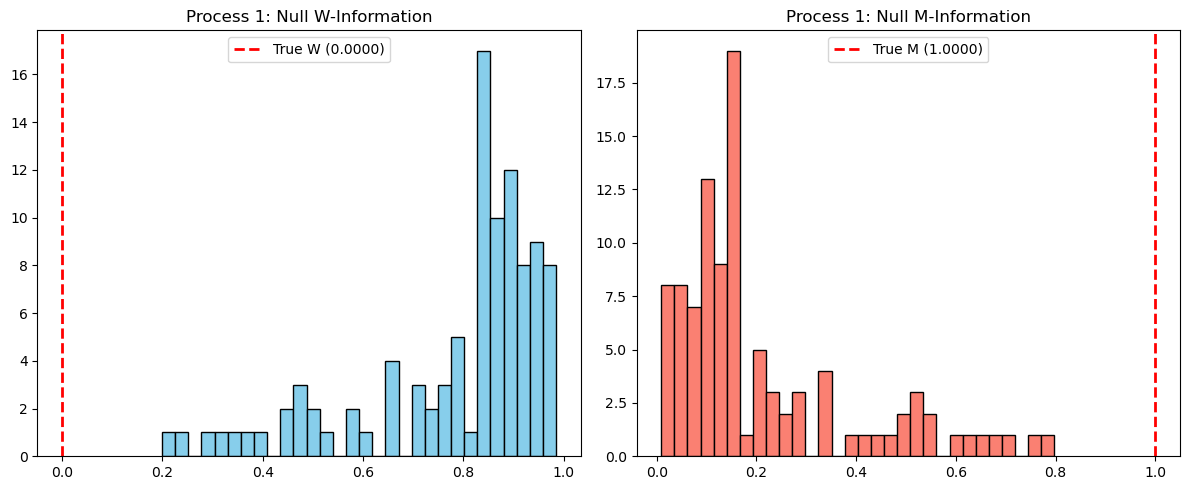

In [5]:
print("Calculating Nulls for Process 1 (XOR)...")
pmf1 = estimate_joint_pmf(X1, Y1, tau=1)
tdmi1 = calculate_tdmi(pmf1)
print(f"Target TDMI 1: {tdmi1:.4f} bits")

null_W1 = []
null_M1 = []

# Use tqdm for progress tracking
for _ in tqdm(range(100)):
    w, m, f1, f2, eta = generate_single_null_wm(tdmi1)
    null_W1.append(w)
    null_M1.append(m)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(null_W1, bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(W1, color='red', linestyle='dashed', linewidth=2, label=f'True W ({W1:.4f})')
axes[0].set_title('Process 1: Null W-Information')
axes[0].legend()

axes[1].hist(null_M1, bins=30, color='salmon', edgecolor='black')
axes[1].axvline(M1, color='red', linestyle='dashed', linewidth=2, label=f'True M ({M1:.4f})')
axes[1].set_title('Process 1: Null M-Information')
axes[1].legend()

plt.tight_layout()
plt.show()

### Null Distribution for Process 2 (COPY)

Calculating Nulls for Process 2 (COPY)...
Target TDMI 2: 1.0000 bits


  0%|          | 0/100 [00:00<?, ?it/s]

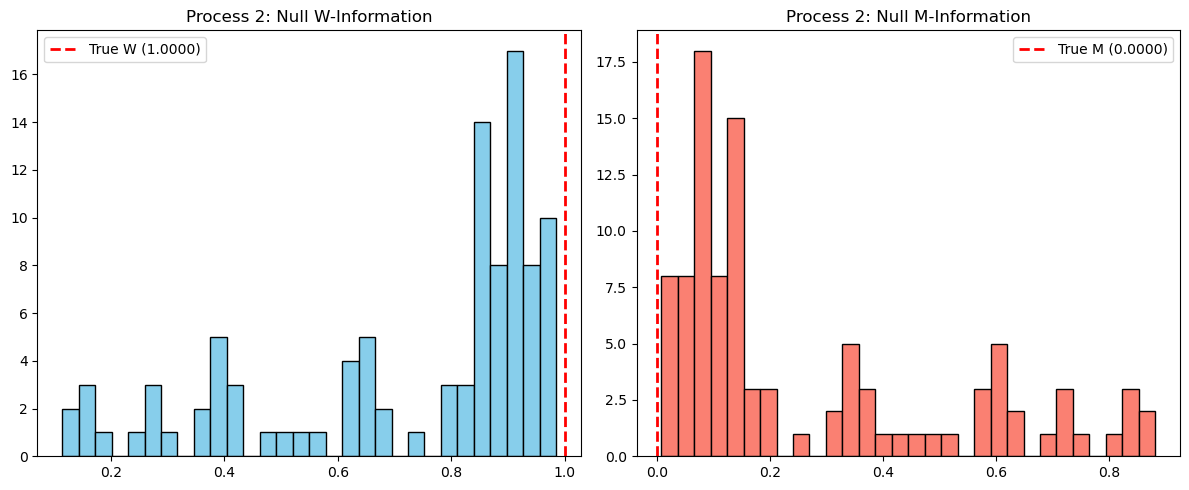

In [6]:
print("Calculating Nulls for Process 2 (COPY)...")
pmf2 = estimate_joint_pmf(X2, Y2, tau=1)
tdmi2 = calculate_tdmi(pmf2)
print(f"Target TDMI 2: {tdmi2:.4f} bits")

null_W2 = []
null_M2 = []

for _ in tqdm(range(100)):
    w, m, f1, f2, eta = generate_single_null_wm(tdmi2)
    null_W2.append(w)
    null_M2.append(m)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(null_W2, bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(W2, color='red', linestyle='dashed', linewidth=2, label=f'True W ({W2:.4f})')
axes[0].set_title('Process 2: Null W-Information')
axes[0].legend()

axes[1].hist(null_M2, bins=30, color='salmon', edgecolor='black')
axes[1].axvline(M2, color='red', linestyle='dashed', linewidth=2, label=f'True M ({M2:.4f})')
axes[1].set_title('Process 2: Null M-Information')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
spks_het = np.load('spk_tensors/2class_fittedhet_ln_spk_tensor.npy')
spks_hom = np.load('spk_tensors/2class_local_hom_spk_tensor.npy')

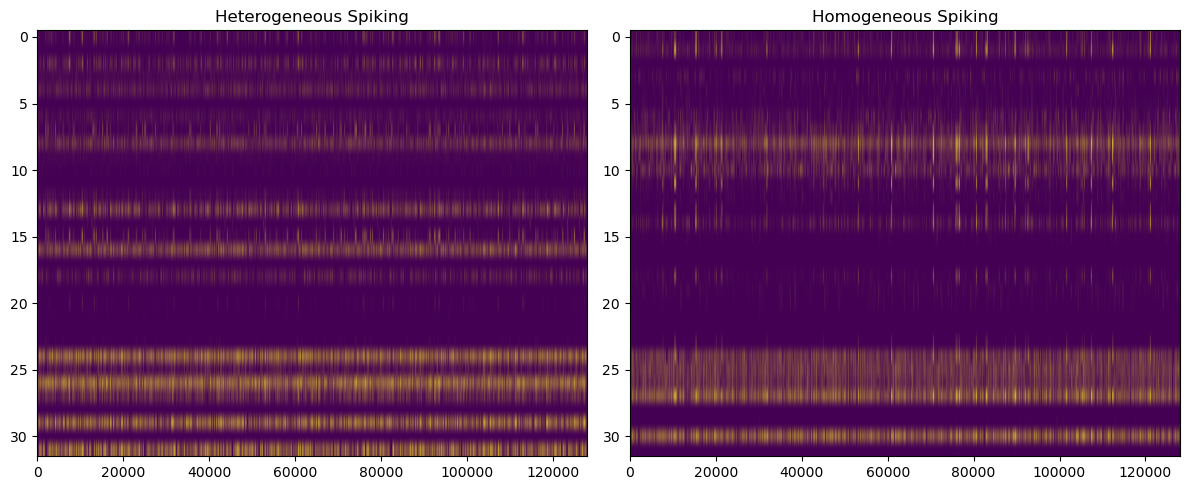

In [8]:
fig,ax = plt.subplots(1,2,figsize=(12,5))
ax[0].imshow(spks_het, aspect='auto', cmap='viridis')
ax[0].set_title('Heterogeneous Spiking')
ax[1].imshow(spks_hom, aspect='auto', cmap='viridis')
ax[1].set_title('Homogeneous Spiking')
plt.tight_layout()
plt.show()

In [9]:
spks_het_fr = spks_het.mean(axis=1)
spks_hom_fr = spks_hom.mean(axis=1)
top_two_het = np.argsort(spks_het_fr)[-2:]
top_two_hom = np.argsort(spks_hom_fr)[-2:]
print(f"Heterogeneous Spiking -> Top 2 Neurons: {top_two_het}, Firing Rates: {spks_het_fr[top_two_het]}")
print(f"Homogeneous Spiking -> Top 2 Neurons: {top_two_hom}, Firing Rates: {spks_hom_fr[top_two_hom]}")

Heterogeneous Spiking -> Top 2 Neurons: [24 26], Firing Rates: [0.3791797 0.4066328]
Homogeneous Spiking -> Top 2 Neurons: [27 30], Firing Rates: [0.3466797  0.35677344]


In [10]:
X_het = spks_het[top_two_het[0]].astype(int)
Y_het = spks_het[top_two_het[1]].astype(int)
X_hom = spks_hom[top_two_hom[0]].astype(int)
Y_hom = spks_hom[top_two_hom[1]].astype(int)

In [11]:
# Prepare data for W-M calculation
data_het = np.array([X_het[:-1], Y_het[:-1], X_het[1:], Y_het[1:]])
data_hom = np.array([X_hom[:-1], Y_hom[:-1], X_hom[1:], Y_hom[1:]])
W_het, M_het = W_M_calculator(data_het, type="discrete", option="data", alphabet_size=2)
W_hom, M_hom = W_M_calculator(data_hom, type="discrete", option="data", alphabet_size=2)
print(f"Heterogeneous Spiking -> W-info: {W_het:.4f} bits, M-info: {M_het:.4f} bits")
print(f"Homogeneous Spiking -> W-info: {W_hom:.4f} bits, M-info: {M_hom:.4f} bits")

Heterogeneous Spiking -> W-info: 0.8581 bits, M-info: 0.0322 bits
Homogeneous Spiking -> W-info: 0.6466 bits, M-info: 0.1119 bits


Heterogeneous Spiking -> Target TDMI: 0.8903 bits


  0%|          | 0/100 [00:00<?, ?it/s]

Heterogeneous Spiking -> W-info Z-score: 1.0947, M-info Z-score: -1.0785


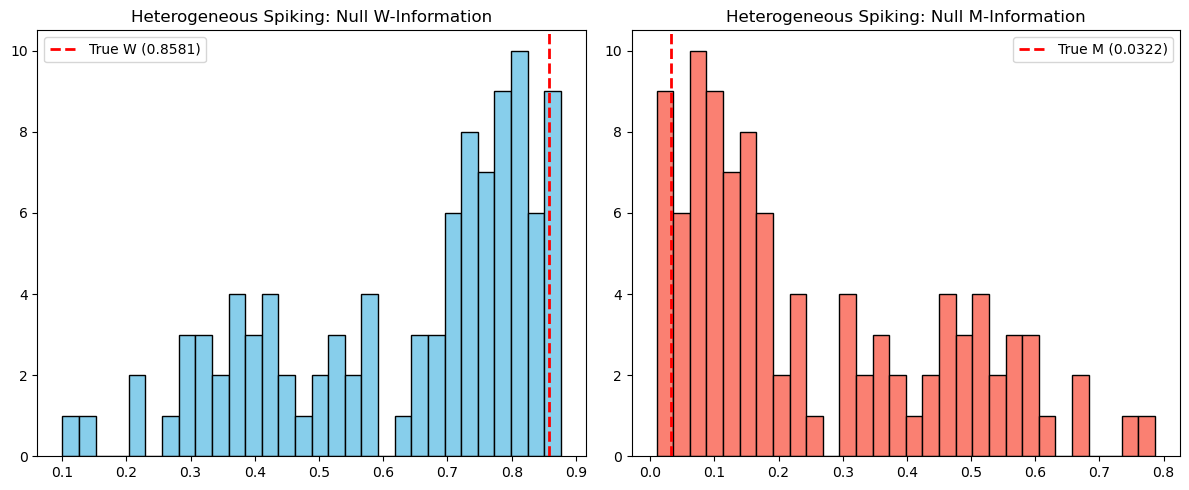

In [12]:
# Null generation for heterogeneous spiking
pmf_het = estimate_joint_pmf(X_het, Y_het, tau=1)
tdmi_het = calculate_tdmi(pmf_het)
print(f"Heterogeneous Spiking -> Target TDMI: {tdmi_het:.4f} bits")
null_W_het = []
null_M_het = []

for _ in tqdm(range(100)):
    w, m, f1, f2, eta = generate_single_null_wm(tdmi_het)
    null_W_het.append(w)
    null_M_het.append(m)

z_score_W_het = (W_het - np.mean(null_W_het)) / np.std(null_W_het)
z_score_M_het = (M_het - np.mean(null_M_het)) / np.std(null_M_het)
print(f"Heterogeneous Spiking -> W-info Z-score: {z_score_W_het:.4f}, M-info Z-score: {z_score_M_het:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(null_W_het, bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(W_het, color='red', linestyle='dashed', linewidth=2, label=f'True W ({W_het:.4f})')
axes[0].set_title('Heterogeneous Spiking: Null W-Information')
axes[0].legend()    
axes[1].hist(null_M_het, bins=30, color='salmon', edgecolor='black')
axes[1].axvline(M_het, color='red', linestyle='dashed', linewidth=2, label=f'True M ({M_het:.4f})')
axes[1].set_title('Heterogeneous Spiking: Null M-Information')
axes[1].legend()
plt.tight_layout()
plt.show()

Homogeneous Spiking -> Target TDMI: 0.7584 bits


  0%|          | 0/100 [00:00<?, ?it/s]

Homogeneous Spiking -> W-info Z-score: 0.6525, M-info Z-score: -0.6368


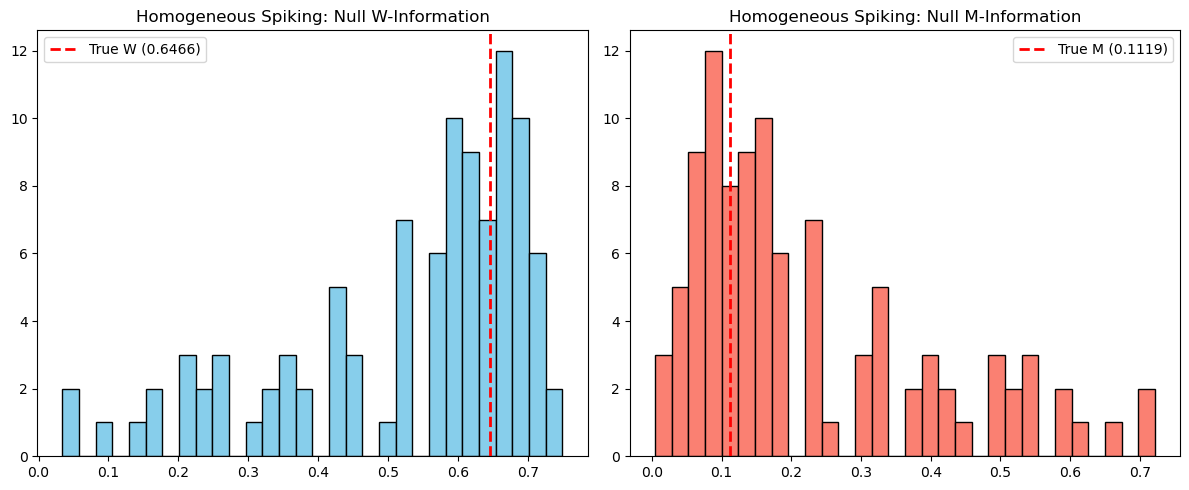

In [13]:
# Null generation for homogeneous spiking
pmf_hom = estimate_joint_pmf(X_hom, Y_hom, tau=1)
tdmi_hom = calculate_tdmi(pmf_hom)
print(f"Homogeneous Spiking -> Target TDMI: {tdmi_hom:.4f} bits")
null_W_hom = []
null_M_hom = []
for _ in tqdm(range(100)):
    w, m, f1, f2, eta = generate_single_null_wm(tdmi_hom)
    null_W_hom.append(w)
    null_M_hom.append(m)

z_score_W_hom = (W_hom - np.mean(null_W_hom)) / np.std(null_W_hom)
z_score_M_hom = (M_hom - np.mean(null_M_hom)) / np.std(null_M_hom)
print(f"Homogeneous Spiking -> W-info Z-score: {z_score_W_hom:.4f}, M-info Z-score: {z_score_M_hom:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(null_W_hom, bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(W_hom, color='red', linestyle='dashed', linewidth=2, label=f'True W ({W_hom:.4f})')
axes[0].set_title('Homogeneous Spiking: Null W-Information')
axes[0].legend()
axes[1].hist(null_M_hom, bins=30, color='salmon', edgecolor='black')
axes[1].axvline(M_hom, color='red', linestyle='dashed', linewidth=2, label=f'True M ({M_hom:.4f})')
axes[1].set_title('Homogeneous Spiking: Null M-Information')
axes[1].legend()
plt.tight_layout()
plt.show()

Number of non-zero neurons in heterogeneous spiking: 26
Number of non-zero neurons in homogeneous spiking: 27


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

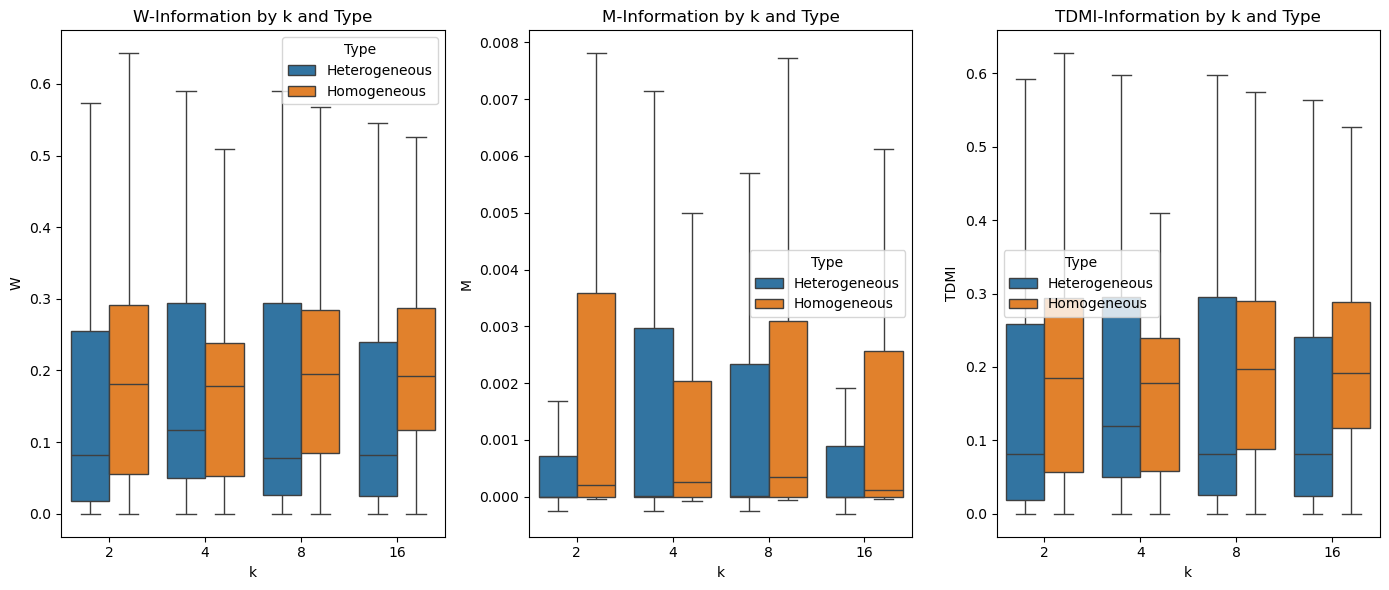

In [29]:
# taking k = [2, 4, 6, 8] neurons at a time and estimate W and M for each subset, 
# Then create a violin plot of the W and M values for each k, comparing heterogeneous and homogeneous spiking.
import seaborn as sns

k_values = [2, 4, 8, 16]
results_het = {k: [] for k in k_values}
results_hom = {k: [] for k in k_values}
spks_het_nz = spks_het[spks_het.sum(axis=1) > 0]
spks_hom_nz = spks_hom[spks_hom.sum(axis=1) > 0]
n_neuron_het = spks_het_nz.shape[0]
n_neuron_hom = spks_hom_nz.shape[0]
print(f"Number of non-zero neurons in heterogeneous spiking: {n_neuron_het}")
print(f"Number of non-zero neurons in homogeneous spiking: {n_neuron_hom}")
num_combinations = 100

for k in k_values:
    for _ in tqdm(range(num_combinations)):
        selected_het = np.random.choice(n_neuron_het, k, replace=False)
        selected_hom = np.random.choice(n_neuron_hom, k, replace=False)
        
        X_het_k = spks_het[selected_het[0]].astype(int)
        Y_het_k = spks_het[selected_het[1]].astype(int)
        data_het_k = np.array([X_het_k[:-1], Y_het_k[:-1], X_het_k[1:], Y_het_k[1:]])
        W_het_k, M_het_k = W_M_calculator(data_het_k, type="discrete", option="data", alphabet_size=2)
        tdmi_het_k = W_het_k + M_het_k
        results_het[k].append((W_het_k, M_het_k, tdmi_het_k))
        
        X_hom_k = spks_hom[selected_hom[0]].astype(int)
        Y_hom_k = spks_hom[selected_hom[1]].astype(int)
        data_hom_k = np.array([X_hom_k[:-1], Y_hom_k[:-1], X_hom_k[1:], Y_hom_k[1:]])
        W_hom_k, M_hom_k = W_M_calculator(data_hom_k, type="discrete", option="data", alphabet_size=2)
        tdmi_hom_k = W_hom_k + M_hom_k
        results_hom[k].append((W_hom_k, M_hom_k, tdmi_hom_k))

# Prepare data for violin plot
import pandas as pd
plot_data = []
for k in k_values:
    for W, M, tdmi in results_het[k]:
        plot_data.append({'k': k, 'W': W, 'M': M, 'TDMI': tdmi, 'Type': 'Heterogeneous'})
    for W, M, tdmi in results_hom[k]:
        plot_data.append({'k': k, 'W': W, 'M': M, 'TDMI': tdmi, 'Type': 'Homogeneous'})
df_plot = pd.DataFrame(plot_data)

# Create violin plots
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='k', y='W', hue='Type', data=df_plot, showfliers=False)
plt.title('W-Information by k and Type')
plt.subplot(1, 3, 2)
sns.boxplot(x='k', y='M', hue='Type', data=df_plot, showfliers=False)
plt.title('M-Information by k and Type')
plt.subplot(1, 3, 3)
sns.boxplot(x='k', y='TDMI', hue='Type', data=df_plot, showfliers=False)
plt.title('TDMI-Information by k and Type')
plt.tight_layout()
plt.show()


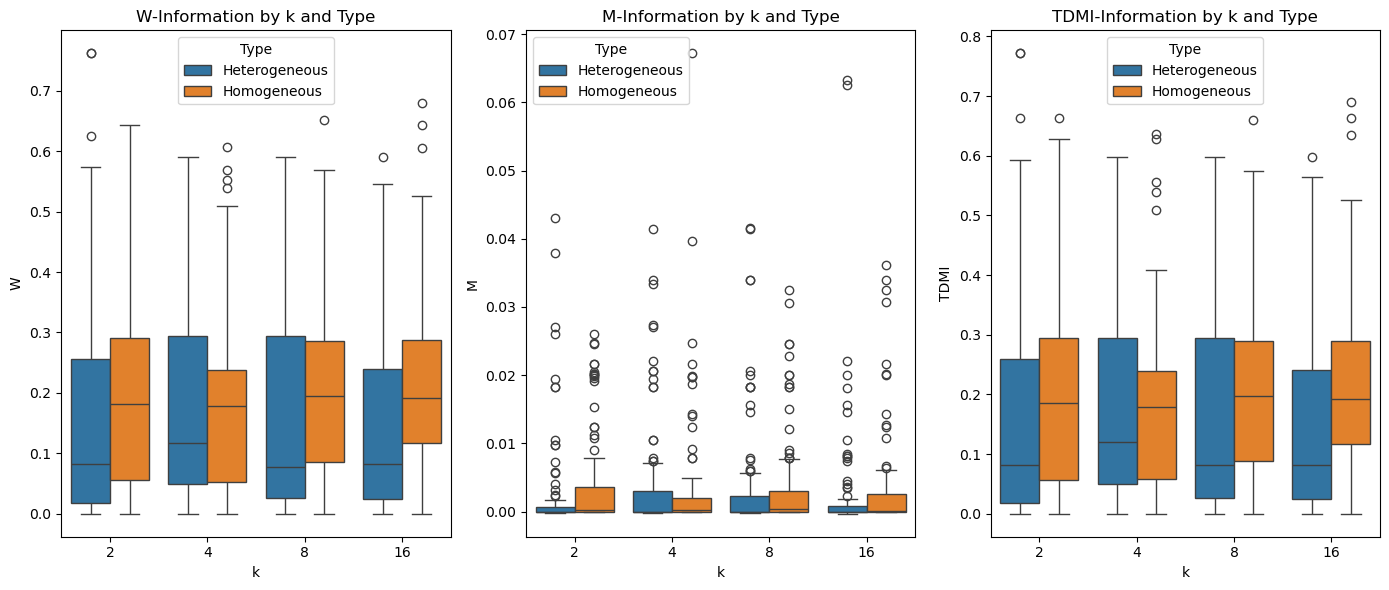

In [30]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='k', y='W', hue='Type', data=df_plot, showfliers=True)
plt.title('W-Information by k and Type')
plt.subplot(1, 3, 2)
sns.boxplot(x='k', y='M', hue='Type', data=df_plot, showfliers=True)
plt.title('M-Information by k and Type')
plt.subplot(1, 3, 3)
sns.boxplot(x='k', y='TDMI', hue='Type', data=df_plot, showfliers=True)
plt.title('TDMI-Information by k and Type')
plt.tight_layout()
plt.show()

### 4-Neuron Multivariate Test on Homogeneous Data

We sample 4 neurons from the homogeneous data, group them into two 2D variables, encode them into 1D with an alphabet size of 4, and compute the W and M information. We then generate 100 nulls using the new multivariate transition function.

4-Neuron Homogeneous -> W-info: 0.2962 bits, M-info: 0.0000 bits, TDMI: 0.2962 bits
Calculating Nulls for 4-Neuron Homogeneous...


  0%|          | 0/100 [00:00<?, ?it/s]

4-Neuron Homogeneous -> W-info Z-score: 7.7338, M-info Z-score: -7.7024


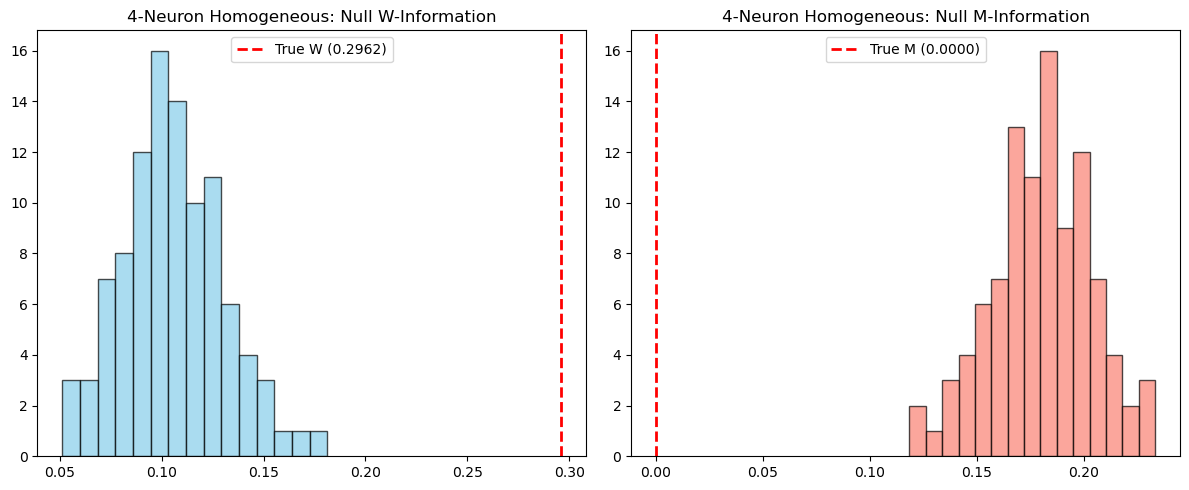

In [14]:
from numit_discrete_optimized import find_transition_for_target_multivariate

def encode_to_1d(multidim_data, base=2):
    D, T = multidim_data.shape
    powers = base ** np.arange(D)
    return powers.dot(multidim_data)

def generate_single_multi_null_wm(target_tdmi, n_vars, alphabet_size, max_tries=500, max_retries=100):
    for _ in range(max_retries):
        try:
            funcs, p_vars, eta, P = find_transition_for_target_multivariate(target_tdmi, n_vars, max_tries=max_tries)
            
            pmf_4d = P.reshape((alphabet_size, alphabet_size, alphabet_size, alphabet_size))
            pmf_4d = pmf_4d + 1e-4
            pmf_4d = pmf_4d / np.sum(pmf_4d)
            
            W, M = W_M_calculator(
                input=pmf_4d,
                type="discrete",
                option="distr",
                alphabet_size=alphabet_size
            )
            return W, M, funcs, p_vars, eta
        except Exception:
            continue
    raise RuntimeError(f"Failed to generate a valid null after {max_retries} retries.")

# 1. Randomly sample 4 neurons from homogeneous data
np.random.seed(42)
idx_4_hom = np.random.choice(spks_hom.shape[0], size=4, replace=False)
spks_4_hom = spks_hom[idx_4_hom, :].astype(int)

# 2. Encode to 1D
S1_2d = spks_4_hom[:2, :-1]
S2_2d = spks_4_hom[2:, :-1]
T1_2d = spks_4_hom[:2, 1:]
T2_2d = spks_4_hom[2:, 1:]

S1_1d = encode_to_1d(S1_2d)
S2_1d = encode_to_1d(S2_2d)
T1_1d = encode_to_1d(T1_2d)
T2_1d = encode_to_1d(T2_2d)

K = 4 # Alphabet size is 2^2 = 4
data_4_hom = np.vstack([S1_1d, S2_1d, T1_1d, T2_1d])

# 3. Calculate true W and M
W_4_hom, M_4_hom = W_M_calculator(data_4_hom, type="discrete", option="data", alphabet_size=K)
tdmi_4_hom = W_4_hom + M_4_hom
print(f"4-Neuron Homogeneous -> W-info: {W_4_hom:.4f} bits, M-info: {M_4_hom:.4f} bits, TDMI: {tdmi_4_hom:.4f} bits")

# 4. Generate Nulls
null_W_multi = []
null_M_multi = []

print("Calculating Nulls for 4-Neuron Homogeneous...")
for _ in tqdm(range(100)):
    w, m, funcs, p_vars, eta = generate_single_multi_null_wm(tdmi_4_hom, n_vars=4, alphabet_size=K)
    null_W_multi.append(w)
    null_M_multi.append(m)

# 5. Print Z-scores and Plot
z_score_W_multi = (W_4_hom - np.mean(null_W_multi)) / np.std(null_W_multi)
z_score_M_multi = (M_4_hom - np.mean(null_M_multi)) / np.std(null_M_multi)
print(f"4-Neuron Homogeneous -> W-info Z-score: {z_score_W_multi:.4f}, M-info Z-score: {z_score_M_multi:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(null_W_multi, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(W_4_hom, color='red', linestyle='dashed', linewidth=2, label=f'True W ({W_4_hom:.4f})')
axes[0].set_title('4-Neuron Homogeneous: Null W-Information')
axes[0].legend()    
axes[1].hist(null_M_multi, bins=15, color='salmon', edgecolor='black', alpha=0.7)
axes[1].axvline(M_4_hom, color='red', linestyle='dashed', linewidth=2, label=f'True M ({M_4_hom:.4f})')
axes[1].set_title('4-Neuron Homogeneous: Null M-Information')
axes[1].legend()
plt.tight_layout()
plt.show()
